# NB12: Bakta Annotation Enrichment of Dark Gene Catalog

## Goal
Enrich the 57,011 dark genes from NB01–NB11 with newly ingested bakta annotations
(bakta v1.12.0, DB v6.0) to:

1. **Reclassify** — how many "dark" genes does bakta actually annotate?
2. **Enrich** — for genes that remain dark, what new annotations does bakta add (EC, GO, KEGG, UniRef50)?
3. **AMR discovery** — are any dark genes actually AMR genes?
4. **Cross-validate** — do ICA module predictions agree with bakta's independent annotations?
5. **Update priorities** — re-score candidates with bakta evidence

## Requirements
- BERDL JupyterHub with `get_spark_session()` (for bakta table queries)
- Upstream data: `dark_gene_census_full.tsv`, `fb_pangenome_link.tsv`, `prioritized_candidates.tsv`

## Inputs
- `data/dark_gene_census_full.tsv` — 57,011 dark genes with darkness tiers and scores
- `data/prioritized_candidates.tsv` — top 100 fitness-active candidates
- `data/dark_gene_classes.tsv` — conservation × darkness classification
- `../conservation_vs_fitness/data/fb_pangenome_link.tsv` — 177,863 FB gene → pangenome cluster links

## Outputs
- `data/bakta_dark_gene_annotations.tsv` — bakta annotations for all linked dark genes
- `data/bakta_reclassified.tsv` — dark genes reclassified by bakta
- `data/bakta_amr_dark_genes.tsv` — dark genes with AMR annotations
- `data/bakta_prediction_validation.tsv` — ICA prediction vs bakta cross-validation
- `data/updated_darkness_tiers.tsv` — revised tier assignments incorporating bakta

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve paths robustly (notebook vs script execution)
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _nb_dir = os.getcwd()
    if not _nb_dir.endswith("notebooks"):
        _nb_dir = os.path.join(_nb_dir, "projects/functional_dark_matter/notebooks")

PROJECT_DIR = os.path.dirname(_nb_dir)
DATA_DIR = os.path.join(PROJECT_DIR, "data")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Spark session
spark = get_spark_session()

DB = "kbase_ke_pangenome"
print(f"Project dir: {PROJECT_DIR}")
print(f"Spark session ready")

Project dir: /home/psdehal/pangenome_science/BERIL-research-observatory/projects/functional_dark_matter
Spark session ready


## Section 1: Load dark gene catalog and pangenome links

In [2]:
# Load dark gene census
dark = pd.read_csv(os.path.join(DATA_DIR, "dark_gene_census_full.tsv"), sep="\t")
print(f"Dark genes loaded: {len(dark):,}")
print(f"Annotation classes:\n{dark['annotation_class'].value_counts()}")
print(f"\nDarkness tiers:\n{dark['darkness_tier'].value_counts().sort_index()}")

# Load FB → pangenome link table
link_path = os.path.join(PROJECT_DIR, "..", "conservation_vs_fitness", "data", "fb_pangenome_link.tsv")
link = pd.read_csv(link_path, sep="\t")
print(f"\nPangenome links loaded: {len(link):,}")

# Merge dark genes with pangenome links
dark_linked = dark.merge(
    link[["orgId", "locusId", "gene_cluster_id"]],
    on=["orgId", "locusId"],
    how="inner"
)
print(f"Dark genes with pangenome link: {len(dark_linked):,} / {len(dark):,} ({100*len(dark_linked)/len(dark):.1f}%)")
print(f"Unique gene_cluster_ids: {dark_linked['gene_cluster_id'].nunique():,}")

Dark genes loaded: 57,011
Annotation classes:
annotation_class
hypothetical       48470
DUF                 3675
uncharacterized     3490
no_annotation       1376
Name: count, dtype: int64

Darkness tiers:
darkness_tier
T1_Void         4273
T2_Twilight    12282
T3_Dusk        16103
T4_Penumbra    22500
T5_Dawn         1853
Name: count, dtype: int64



Pangenome links loaded: 177,863
Dark genes with pangenome link: 39,532 / 57,011 (69.3%)
Unique gene_cluster_ids: 37,181


## Section 2: Query bakta annotations for dark gene clusters

Upload the unique gene_cluster_ids to Spark as a temp view, then JOIN against
`bakta_annotations`, `bakta_pfam_domains`, and `bakta_amr`.

In [3]:
# Create temp view of target gene_cluster_ids for efficient Spark JOIN
target_ids = dark_linked[["gene_cluster_id"]].drop_duplicates()
target_ids["gene_cluster_id"] = target_ids["gene_cluster_id"].astype(str)
spark_targets = spark.createDataFrame(target_ids)
spark_targets.createOrReplaceTempView("dark_cluster_ids")
print(f"Registered {target_ids.shape[0]:,} unique cluster IDs as Spark temp view")

Registered 37,181 unique cluster IDs as Spark temp view


In [4]:
# Query bakta_annotations for our dark gene clusters
bakta_ann = spark.sql(f"""
    SELECT b.*
    FROM {DB}.bakta_annotations b
    JOIN dark_cluster_ids d ON b.gene_cluster_id = d.gene_cluster_id
""").toPandas()
print(f"Bakta annotations retrieved: {len(bakta_ann):,}")
print(f"\nBakta columns: {list(bakta_ann.columns)}")
print(f"\nBakta hypothetical breakdown:")
print(bakta_ann["hypothetical"].value_counts())

Bakta annotations retrieved: 37,181

Bakta columns: ['gene_cluster_id', 'length', 'gene', 'product', 'hypothetical', 'ec', 'go', 'cog_id', 'cog_category', 'kegg_orthology_id', 'refseq', 'uniparc', 'uniref100', 'uniref90', 'uniref50', 'molecular_weight', 'isoelectric_point']

Bakta hypothetical breakdown:
hypothetical
False    31311
True      5870
Name: count, dtype: int64


In [5]:
# Query bakta_pfam_domains for dark gene clusters
bakta_pfam = spark.sql(f"""
    SELECT p.*
    FROM {DB}.bakta_pfam_domains p
    JOIN dark_cluster_ids d ON p.gene_cluster_id = d.gene_cluster_id
""").toPandas()
print(f"Bakta Pfam domain hits for dark genes: {len(bakta_pfam):,}")
print(f"Unique dark clusters with Pfam: {bakta_pfam['gene_cluster_id'].nunique():,}")

# Query bakta_amr for dark gene clusters
bakta_amr = spark.sql(f"""
    SELECT a.*
    FROM {DB}.bakta_amr a
    JOIN dark_cluster_ids d ON a.gene_cluster_id = d.gene_cluster_id
""").toPandas()
print(f"\nBakta AMR hits for dark genes: {len(bakta_amr):,}")
if len(bakta_amr) > 0:
    print(bakta_amr[["gene_cluster_id", "amr_gene", "amr_product", "identity"]].to_string())

Bakta Pfam domain hits for dark genes: 362
Unique dark clusters with Pfam: 235



Bakta AMR hits for dark genes: 5
          gene_cluster_id amr_gene                                                       amr_product  identity
0  NZ_CAJHOC010000040.1_9  hdeD-GI                          heat resistance membrane protein HdeD-GI    0.9113
1     NZ_VKMF01000023.1_1      asr                      acid resistance repetitive basic protein Asr       NaN
2         CP056418.1_2630     ybtP  yersiniabactin ABC transporter ATP-binding/permease protein YbtP    0.9065
3         NC_017506.1_193     merF                  mercury resistance system transport protein MerF       NaN
4        NC_009092.1_3900     s025                                               S8 family peptidase    0.9044


## Section 3: Reclassification — how many dark genes does bakta annotate?

A gene is "reclassified" if FB calls it hypothetical/DUF/uncharacterized but bakta
assigns `hypothetical=false` (i.e., bakta found a product description via PSC/PSCC).

In [6]:
# Merge bakta annotations onto dark_linked
# Note: both tables have 'gene' column (FB gene name vs bakta gene name)
# so suffix applies there → 'gene_bakta'. But 'hypothetical' only exists
# in bakta, so it stays 'hypothetical' (no suffix needed).
dark_bakta = dark_linked.merge(
    bakta_ann,
    on="gene_cluster_id",
    how="left",
    suffixes=("", "_bakta")
)

# bakta's hypothetical field — may come as string 'true'/'false' from Spark
hyp_col = "hypothetical" if "hypothetical" in dark_bakta.columns else "hypothetical_bakta"
if dark_bakta[hyp_col].dtype == object:
    dark_bakta["bakta_hypothetical"] = dark_bakta[hyp_col].str.lower() == "true"
else:
    dark_bakta["bakta_hypothetical"] = dark_bakta[hyp_col].fillna(True).astype(bool)

# Reclassified = FB says dark, bakta says NOT hypothetical
dark_bakta["bakta_reclassified"] = ~dark_bakta["bakta_hypothetical"]
n_reclassified = dark_bakta["bakta_reclassified"].sum()
n_linked = len(dark_bakta)

print(f"Dark genes with bakta annotations: {n_linked:,}")
print(f"Bakta reclassifies as NOT hypothetical: {n_reclassified:,} ({100*n_reclassified/n_linked:.1f}%)")
print(f"Bakta agrees — still hypothetical: {n_linked - n_reclassified:,} ({100*(n_linked-n_reclassified)/n_linked:.1f}%)")
print(f"\nReclassified by FB annotation class:")
print(dark_bakta[dark_bakta["bakta_reclassified"]]["annotation_class"].value_counts())
print(f"\nReclassified by darkness tier:")
print(dark_bakta[dark_bakta["bakta_reclassified"]]["darkness_tier"].value_counts().sort_index())

Dark genes with bakta annotations: 39,532
Bakta reclassifies as NOT hypothetical: 33,105 (83.7%)
Bakta agrees — still hypothetical: 6,427 (16.3%)

Reclassified by FB annotation class:
annotation_class
hypothetical       28067
uncharacterized     2560
DUF                 2417
no_annotation         61
Name: count, dtype: int64

Reclassified by darkness tier:
darkness_tier
T2_Twilight     3320
T3_Dusk         8893
T4_Penumbra    19101
T5_Dawn         1791
Name: count, dtype: int64


In [7]:
# Show example reclassified genes — what does bakta call them?
reclass = dark_bakta[dark_bakta["bakta_reclassified"]].copy()
if len(reclass) > 0:
    print(f"Sample reclassified genes (FB desc → bakta product):\n")
    sample = reclass.nlargest(20, "max_abs_fit") if "max_abs_fit" in reclass.columns else reclass.head(20)
    for _, row in sample.iterrows():
        fit_str = f"|fit|={row['max_abs_fit']:.1f}" if pd.notna(row.get("max_abs_fit")) else "essential"
        print(f"  {row['orgId']:20s} {row['locusId']:15s} {fit_str:12s} FB: {str(row['desc'])[:40]:40s} → Bakta: {str(row.get('product', ''))[:50]}")
else:
    print("No reclassified genes found.")

Sample reclassified genes (FB desc → bakta product):

  DvH                  209183          |fit|=13.4   FB: hypothetical protein (TIGR)              → Bakta: DUF106 domain-containing protein
  Cup4G11              RR42_RS19880    |fit|=11.5   FB: hypothetical protein                     → Bakta: Transcriptional regulator, TetR family
  DvH                  11399186        |fit|=10.5   FB: nan                                      → Bakta: Dinitrogenase iron-molybdenum cofactor biosynthesi
  MR1                  203749          |fit|=10.1   FB: conserved hypothetical protein (NCBI ptt → Bakta: CDP-glycerol glycerophosphotransferase family prot
  PV4                  5207783         |fit|=9.9    FB: hypothetical protein (RefSeq)            → Bakta: ubiquinone biosynthesis accessory factor UbiK
  Keio                 17261           |fit|=9.7    FB: orf, hypothetical protein (VIMSS)        → Bakta: BolA family iron metabolism protein IbaG
  PV4                  5209657         |fit|=9.7 

## Section 4: Annotation enrichment — new EC, GO, KEGG, UniRef50

For dark genes that remain dark (bakta also calls them hypothetical), what
new functional annotations does bakta provide?

In [8]:
# Annotation coverage: ALL linked dark genes (including reclassified)
def has_value(series):
    """True where value is non-null and non-empty string."""
    return series.notna() & (series.astype(str).str.strip() != "") & (series.astype(str) != "nan")

annot_fields = {
    "gene_bakta": "gene_bakta" if "gene_bakta" in dark_bakta.columns else "gene",
    "product": "product",
    "ec": "ec",
    "go": "go",
    "cog_id": "cog_id",
    "kegg_orthology_id": "kegg_orthology_id",
    "uniref50": "uniref50",
    "uniref90": "uniref90",
    "uniref100": "uniref100",
    "uniparc": "uniparc",
    "refseq": "refseq",
}

# Filter to columns that actually exist
annot_fields = {k: v for k, v in annot_fields.items() if v in dark_bakta.columns}

print(f"Bakta annotation coverage for {len(dark_bakta):,} linked dark genes:\n")
print(f"{'Annotation':<25} {'Has value':>10} {'%':>7}")
print("-" * 45)
for label, col in annot_fields.items():
    n = has_value(dark_bakta[col]).sum()
    print(f"{label:<25} {n:>10,} {100*n/len(dark_bakta):>6.1f}%")

# Pfam coverage (from separate table)
dark_with_pfam = dark_linked[dark_linked["gene_cluster_id"].isin(bakta_pfam["gene_cluster_id"])]
print(f"\n{'bakta_pfam_domains':<25} {len(dark_with_pfam):>10,} {100*len(dark_with_pfam)/len(dark_bakta):>6.1f}%")

Bakta annotation coverage for 39,532 linked dark genes:

Annotation                 Has value       %
---------------------------------------------
gene_bakta                     8,820   22.3%
product                       39,532  100.0%
ec                             1,057    2.7%
go                             1,357    3.4%
cog_id                         7,341   18.6%
kegg_orthology_id              3,442    8.7%
uniref50                      38,163   96.5%
uniref90                      33,990   86.0%
uniref100                     33,990   86.0%
uniparc                       33,990   86.0%
refseq                        32,213   81.5%

bakta_pfam_domains               288    0.7%


In [9]:
# Same coverage but split by reclassified vs still-dark
print("Coverage split: bakta-reclassified vs still-dark\n")
for label, subset_name, mask in [
    ("Reclassified (bakta annotated)", "reclass", dark_bakta["bakta_reclassified"]),
    ("Still dark (bakta hypothetical)", "dark", ~dark_bakta["bakta_reclassified"]),
]:
    sub = dark_bakta[mask]
    print(f"\n--- {label} ({len(sub):,} genes) ---")
    for field_label, col in annot_fields.items():
        if col in sub.columns:
            n = has_value(sub[col]).sum()
            print(f"  {field_label:<25} {n:>8,} ({100*n/max(len(sub),1):.1f}%)")

Coverage split: bakta-reclassified vs still-dark


--- Reclassified (bakta annotated) (33,105 genes) ---
  gene_bakta                   8,820 (26.6%)
  product                     33,105 (100.0%)
  ec                           1,055 (3.2%)
  go                           1,357 (4.1%)
  cog_id                       7,340 (22.2%)
  kegg_orthology_id            3,429 (10.4%)
  uniref50                    33,063 (99.9%)
  uniref90                    29,548 (89.3%)
  uniref100                   29,548 (89.3%)
  uniparc                     29,548 (89.3%)
  refseq                      28,203 (85.2%)

--- Still dark (bakta hypothetical) (6,427 genes) ---
  gene_bakta                       0 (0.0%)
  product                      6,427 (100.0%)
  ec                               2 (0.0%)
  go                               0 (0.0%)
  cog_id                           1 (0.0%)
  kegg_orthology_id               13 (0.2%)
  uniref50                     5,100 (79.4%)
  uniref90                     4,44

## Section 5: AMR discovery — are any dark genes actually antimicrobial resistance genes?

In [10]:
# AMR dark genes
if len(bakta_amr) > 0:
    amr_dark = dark_linked.merge(
        bakta_amr,
        on="gene_cluster_id",
        how="inner"
    )
    print(f"Dark genes with AMR annotations: {len(amr_dark):,}")
    print(f"Unique AMR genes: {amr_dark['amr_gene'].nunique()}")
    print(f"\nAMR dark genes detail:")
    display_cols = ["orgId", "locusId", "desc", "annotation_class", "darkness_tier",
                    "amr_gene", "amr_product", "method", "identity"]
    display_cols = [c for c in display_cols if c in amr_dark.columns]
    print(amr_dark[display_cols].to_string(index=False))

    # Save
    amr_dark.to_csv(os.path.join(DATA_DIR, "bakta_amr_dark_genes.tsv"), sep="\t", index=False)
    print(f"\nSaved to data/bakta_amr_dark_genes.tsv")
else:
    print("No dark genes have bakta AMR annotations.")

Dark genes with AMR annotations: 5
Unique AMR genes: 5

AMR dark genes detail:
 orgId       locusId                                     desc annotation_class darkness_tier amr_gene                                                      amr_product method  identity
  Koxy BWI76_RS14520                     hypothetical protein     hypothetical   T4_Penumbra     ybtP yersiniabactin ABC transporter ATP-binding/permease protein YbtP BLASTP    0.9065
Marino        GFF193 conserved hypothetical protein, membrane     hypothetical   T4_Penumbra     merF                 mercury resistance system transport protein MerF    HMM       NaN
    PS     Dsui_1498                     hypothetical protein     hypothetical   T4_Penumbra  hdeD-GI                         heat resistance membrane protein HdeD-GI BLASTP    0.9113
   PV4       5211455            hypothetical protein (RefSeq)     hypothetical   T4_Penumbra     s025                                              S8 family peptidase BLASTP    0.9044
 


Saved to data/bakta_amr_dark_genes.tsv


## Section 6: Cross-validate ICA module predictions against bakta

For dark genes with ICA module-based function predictions (from `fitness_modules`),
check whether bakta's independent annotations agree.

In [11]:
# Cross-validate ICA predictions vs bakta annotations
# Genes with module predictions AND bakta annotations
has_prediction = dark_bakta["module_prediction"].notna() & (dark_bakta["module_prediction"].astype(str).str.strip() != "")
has_bakta_product = dark_bakta["bakta_reclassified"]

predicted_and_bakta = dark_bakta[has_prediction & has_bakta_product].copy()
predicted_no_bakta = dark_bakta[has_prediction & ~has_bakta_product].copy()

print(f"Dark genes with ICA module prediction: {has_prediction.sum():,}")
print(f"  Also reclassified by bakta:          {len(predicted_and_bakta):,}")
print(f"  Bakta still calls hypothetical:      {len(predicted_no_bakta):,}")

if len(predicted_and_bakta) > 0:
    print(f"\nCross-validation: ICA prediction vs bakta product (top examples):\n")
    sample = predicted_and_bakta.head(30)
    for _, row in sample.iterrows():
        pred = str(row["module_prediction"])[:45]
        bakta_prod = str(row.get("product", ""))[:45]
        print(f"  {row['orgId']:15s} {row['locusId']:12s}  ICA: {pred:45s}  Bakta: {bakta_prod}")

# Save cross-validation table
if len(predicted_and_bakta) > 0:
    cv_cols = ["orgId", "locusId", "desc", "module_prediction", "product",
               "gene_cluster_id", "ec", "go", "kegg_orthology_id", "cog_id"]
    cv_cols = [c for c in cv_cols if c in predicted_and_bakta.columns]
    predicted_and_bakta[cv_cols].to_csv(
        os.path.join(DATA_DIR, "bakta_prediction_validation.tsv"), sep="\t", index=False
    )
    print(f"\nSaved to data/bakta_prediction_validation.tsv")

Dark genes with ICA module prediction: 3,878
  Also reclassified by bakta:          3,406
  Bakta still calls hypothetical:      472

Cross-validation: ICA prediction vs bakta product (top examples):

  acidovorax_3H11 Ac3H11_1334   ICA: serine/threonine protein kinase                Bakta: N-methyl-D-aspartate receptor NMDAR2C subunit
  acidovorax_3H11 Ac3H11_1380   ICA: serine/threonine protein kinase                Bakta: Flagellar protein FlgN
  acidovorax_3H11 Ac3H11_1546   ICA: Bacillosamine/Legionaminic acid biosynthesis   Bakta: GCN5 family acetyltransferase
  acidovorax_3H11 Ac3H11_1550   ICA: Bacillosamine/Legionaminic acid biosynthesis   Bakta: UDP-glycosyltransferase
  acidovorax_3H11 Ac3H11_1596   ICA: Transcriptional regulator, MarR family         Bakta: Fatty acid desaturase
  acidovorax_3H11 Ac3H11_2196   ICA: serine/threonine protein kinase                Bakta: DUF697 domain-containing protein
  acidovorax_3H11 Ac3H11_2405   ICA: Transcriptional regulator, GntR family

## Section 7: Impact on prioritized candidates

Check which of the top 100 fitness-active candidates and top 50 essential
candidates gain bakta annotations.

In [12]:
# Load prioritized candidates
candidates = pd.read_csv(os.path.join(DATA_DIR, "prioritized_candidates.tsv"), sep="\t")
print(f"Prioritized candidates loaded: {len(candidates):,}")

# Merge candidates with bakta (rename bakta cols to avoid collisions)
bakta_for_cand = bakta_ann.rename(columns={"gene": "bakta_gene_name"})
cand_bakta = candidates.merge(
    bakta_for_cand,
    on="gene_cluster_id",
    how="left",
    suffixes=("", "_bakta")
)

# Check which candidates bakta annotates (hypothetical=false)
hyp_col_cand = "hypothetical" if "hypothetical" in cand_bakta.columns else "hypothetical_bakta"
if cand_bakta[hyp_col_cand].dtype == object:
    cand_bakta["bakta_annotated"] = cand_bakta[hyp_col_cand].str.lower() == "false"
else:
    cand_bakta["bakta_annotated"] = ~cand_bakta[hyp_col_cand].fillna(True).astype(bool)

n_annotated = cand_bakta["bakta_annotated"].sum()
print(f"\nOf {len(candidates)} prioritized candidates:")
print(f"  Bakta provides annotation: {n_annotated} ({100*n_annotated/len(candidates):.0f}%)")
print(f"  Has UniRef50 link:         {has_value(cand_bakta['uniref50']).sum()}")
print(f"  Has EC number:             {has_value(cand_bakta['ec']).sum()}")
print(f"  Has GO terms:              {has_value(cand_bakta['go']).sum()}")
print(f"  Has KEGG KO:               {has_value(cand_bakta['kegg_orthology_id']).sum()}")
print(f"  Has COG:                   {has_value(cand_bakta['cog_id']).sum()}")

# Show bakta-annotated candidates
if n_annotated > 0:
    print(f"\nPrioritized candidates now annotated by bakta:\n")
    annotated = cand_bakta[cand_bakta["bakta_annotated"]].copy()
    for i, (_, row) in enumerate(annotated.iterrows()):
        print(f"  Rank {i + 1:3d}: {row['orgId']:15s} {row['locusId']:12s} "
              f"score={row['total_score']:.3f}  "
              f"Bakta: {str(row.get('product', ''))[:60]}")

Prioritized candidates loaded: 100

Of 100 prioritized candidates:
  Bakta provides annotation: 100 (100%)
  Has UniRef50 link:         99
  Has EC number:             10
  Has GO terms:              12
  Has KEGG KO:               31
  Has COG:                   45

Prioritized candidates now annotated by bakta:

  Rank   1: pseudo5_N2C3_1  AO356_11255  score=0.715  Bakta: EamA domain-containing protein
  Rank   2: MR1             202463       score=0.698  Bakta: YggT family protein
  Rank   3: MR1             199738       score=0.698  Bakta: TIGR02001 family outer membrane protein
  Rank   4: MR1             203545       score=0.694  Bakta: putative periplasmic protein
  Rank   5: MR1             202450       score=0.693  Bakta: Glycine transporter domain-containing protein
  Rank   6: pseudo5_N2C3_1  AO356_18320  score=0.689  Bakta: OmpA-like domain-containing protein
  Rank   7: pseudo1_N1B4    Pf1N1B4_3696 score=0.687  Bakta: Dehydrogenase
  Rank   8: MR1             201124       

## Section 8: Updated darkness tiers

Recalculate the 5-tier darkness spectrum incorporating bakta as a new evidence line.
- Genes reclassified by bakta gain `has_bakta_annotation` as an evidence flag
- Genes with bakta UniRef50 gain `has_uniref50` as a new cross-reference axis
- Tier boundaries shift: some T1 Void genes may move up

In [13]:
# Merge bakta flags back onto full dark gene census (including unlinked)
dark_updated = dark.copy()

# Create bakta flag columns (default False for unlinked genes)
bakta_flags = dark_bakta[["orgId", "locusId", "bakta_reclassified"]].copy()
bakta_flags["has_bakta_annotation"] = dark_bakta["bakta_reclassified"]
bakta_flags["has_bakta_uniref50"] = has_value(dark_bakta["uniref50"]) if "uniref50" in dark_bakta.columns else False
bakta_flags["has_bakta_ec"] = has_value(dark_bakta["ec"]) if "ec" in dark_bakta.columns else False
bakta_flags["has_bakta_go"] = has_value(dark_bakta["go"]) if "go" in dark_bakta.columns else False

dark_updated = dark_updated.merge(
    bakta_flags[["orgId", "locusId", "has_bakta_annotation", "has_bakta_uniref50",
                 "has_bakta_ec", "has_bakta_go"]],
    on=["orgId", "locusId"],
    how="left"
)
for col in ["has_bakta_annotation", "has_bakta_uniref50", "has_bakta_ec", "has_bakta_go"]:
    dark_updated[col] = dark_updated[col].fillna(False)

# Recount evidence lines including bakta
evidence_cols_orig = ["has_domain", "has_ortholog_group", "has_function_prediction",
                      "has_cofit_partner", "has_phenotype", "has_pangenome_context"]
evidence_cols_new = evidence_cols_orig + ["has_bakta_annotation"]

dark_updated["n_evidence_lines_updated"] = dark_updated[evidence_cols_new].sum(axis=1).astype(int)

# Assign updated darkness tiers using same scheme as NB09
def assign_tier(n):
    if n == 0:
        return "T1_Void"
    elif n == 1:
        return "T2_Twilight"
    elif n == 2:
        return "T3_Dusk"
    elif n <= 4:
        return "T4_Penumbra"
    else:
        return "T5_Dawn"

dark_updated["darkness_tier_updated"] = dark_updated["n_evidence_lines_updated"].apply(assign_tier)

# Compare old vs new tiers
print("Darkness tier comparison (original → updated):\n")
tier_compare = pd.crosstab(dark_updated["darkness_tier"], dark_updated["darkness_tier_updated"])
print(tier_compare)

# Summarize tier changes
changed = dark_updated["darkness_tier"] != dark_updated["darkness_tier_updated"]
print(f"\nGenes that changed tier: {changed.sum():,} / {len(dark_updated):,} ({100*changed.sum()/len(dark_updated):.1f}%)")
print(f"\nUpdated tier distribution:")
print(dark_updated["darkness_tier_updated"].value_counts().sort_index())

Darkness tier comparison (original → updated):


darkness_tier_updated  T1_Void  T2_Twilight  T3_Dusk  T4_Penumbra  T5_Dawn
darkness_tier                                                             
T1_Void                   4273            0        0            0        0
T2_Twilight                  0         8962     3320            0        0
T3_Dusk                      0            0     7210         8893        0
T4_Penumbra                  0            0        0        16694     5806
T5_Dawn                      0            0        0            0     1853

Genes that changed tier: 18,019 / 57,011 (31.6%)

Updated tier distribution:
darkness_tier_updated
T1_Void         4273
T2_Twilight     8962
T3_Dusk        10530
T4_Penumbra    25587
T5_Dawn         7659
Name: count, dtype: int64


## Section 9: Summary figures

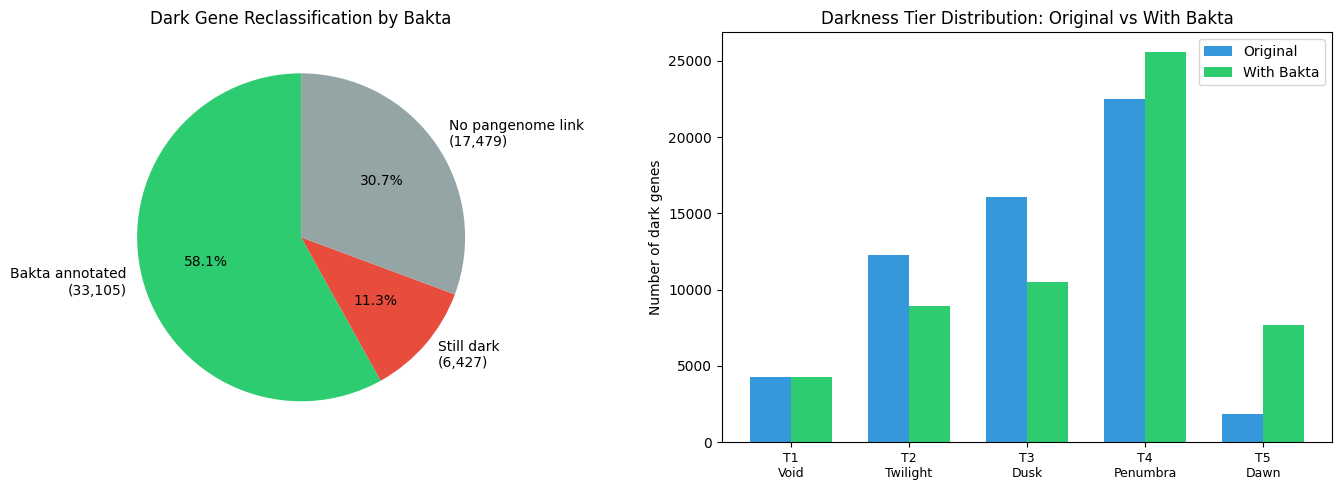

Saved figures/fig33_bakta_reclassification.png


In [14]:
# Figure 1: Reclassification breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pie chart — reclassified vs still dark vs no link
n_no_link = len(dark) - len(dark_linked)
n_still_dark = len(dark_linked) - n_reclassified
sizes = [n_reclassified, n_still_dark, n_no_link]
labels = [f"Bakta annotated\n({n_reclassified:,})",
          f"Still dark\n({n_still_dark:,})",
          f"No pangenome link\n({n_no_link:,})"]
colors = ["#2ecc71", "#e74c3c", "#95a5a6"]
axes[0].pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Dark Gene Reclassification by Bakta")

# Right: tier comparison (stacked bar)
tier_order = ["T1_Void", "T2_Twilight", "T3_Dusk", "T4_Penumbra", "T5_Dawn"]
orig_counts = dark_updated["darkness_tier"].value_counts().reindex(tier_order, fill_value=0)
updated_counts = dark_updated["darkness_tier_updated"].value_counts().reindex(tier_order, fill_value=0)

x = np.arange(len(tier_order))
width = 0.35
axes[1].bar(x - width/2, orig_counts.values, width, label="Original", color="#3498db")
axes[1].bar(x + width/2, updated_counts.values, width, label="With Bakta", color="#2ecc71")
axes[1].set_xticks(x)
axes[1].set_xticklabels([t.replace("_", "\n") for t in tier_order], fontsize=9)
axes[1].set_ylabel("Number of dark genes")
axes[1].set_title("Darkness Tier Distribution: Original vs With Bakta")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig33_bakta_reclassification.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig33_bakta_reclassification.png")

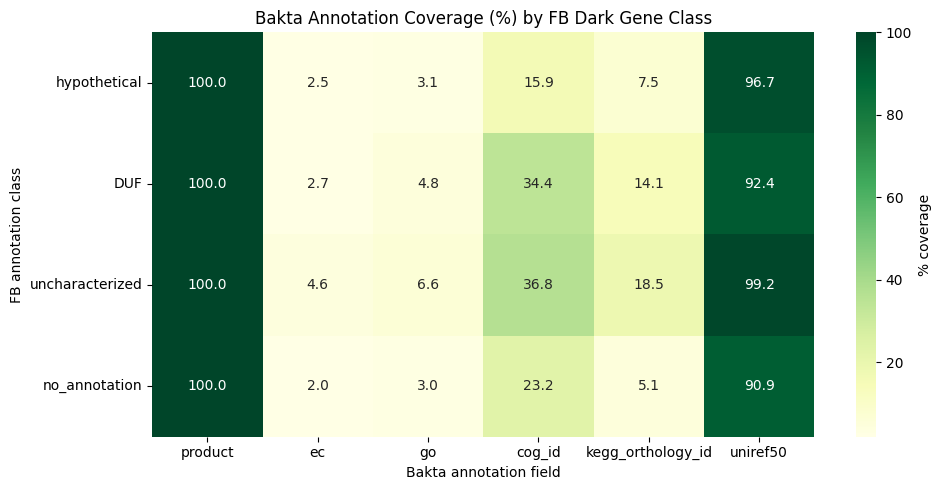

Saved figures/fig34_bakta_coverage_heatmap.png


In [15]:
# Figure 2: Bakta annotation coverage heatmap for linked dark genes
fig, ax = plt.subplots(figsize=(10, 5))

# Build coverage matrix by annotation class
annot_classes = ["hypothetical", "DUF", "uncharacterized", "no_annotation"]
bakta_fields = ["product", "ec", "go", "cog_id", "kegg_orthology_id", "uniref50"]
bakta_fields = [f for f in bakta_fields if f in dark_bakta.columns]

coverage_matrix = []
for ac in annot_classes:
    row_data = []
    subset = dark_bakta[dark_bakta["annotation_class"] == ac]
    for field in bakta_fields:
        pct = 100 * has_value(subset[field]).sum() / max(len(subset), 1)
        row_data.append(pct)
    coverage_matrix.append(row_data)

cov_df = pd.DataFrame(coverage_matrix, index=annot_classes, columns=bakta_fields)
sns.heatmap(cov_df, annot=True, fmt=".1f", cmap="YlGn", ax=ax,
            cbar_kws={"label": "% coverage"})
ax.set_title("Bakta Annotation Coverage (%) by FB Dark Gene Class")
ax.set_ylabel("FB annotation class")
ax.set_xlabel("Bakta annotation field")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig34_bakta_coverage_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig34_bakta_coverage_heatmap.png")

## Section 10: Save outputs

In [16]:
# Save all bakta annotations for linked dark genes
bakta_cols = ["orgId", "locusId", "gene_cluster_id", "desc", "annotation_class",
              "darkness_tier", "bakta_reclassified"]
# Add bakta annotation columns
for col in ["product", "gene_bakta", "ec", "go", "cog_id", "cog_category",
            "kegg_orthology_id", "uniref50", "uniref90", "uniref100",
            "uniparc", "refseq", "molecular_weight", "isoelectric_point"]:
    if col in dark_bakta.columns:
        bakta_cols.append(col)

dark_bakta[bakta_cols].to_csv(
    os.path.join(DATA_DIR, "bakta_dark_gene_annotations.tsv"), sep="\t", index=False
)
print(f"Saved data/bakta_dark_gene_annotations.tsv ({len(dark_bakta):,} rows)")

# Save reclassified genes
reclass_out = dark_bakta[dark_bakta["bakta_reclassified"]].copy()
reclass_out[bakta_cols].to_csv(
    os.path.join(DATA_DIR, "bakta_reclassified.tsv"), sep="\t", index=False
)
print(f"Saved data/bakta_reclassified.tsv ({len(reclass_out):,} rows)")

# Save updated darkness tiers
tier_cols = ["orgId", "locusId", "desc", "annotation_class",
             "darkness_tier", "darkness_tier_updated", "n_evidence_lines",
             "n_evidence_lines_updated", "has_bakta_annotation",
             "has_bakta_uniref50", "has_bakta_ec", "has_bakta_go"]
tier_cols = [c for c in tier_cols if c in dark_updated.columns]
dark_updated[tier_cols].to_csv(
    os.path.join(DATA_DIR, "updated_darkness_tiers.tsv"), sep="\t", index=False
)
print(f"Saved data/updated_darkness_tiers.tsv ({len(dark_updated):,} rows)")

# Summary
print(f"\n{'=' * 60}")
print(f"NB12 SUMMARY")
print(f"{'=' * 60}")
print(f"Total dark genes:                {len(dark):,}")
print(f"With pangenome link:             {len(dark_linked):,} ({100*len(dark_linked)/len(dark):.1f}%)")
print(f"Bakta reclassifies as annotated: {n_reclassified:,} ({100*n_reclassified/len(dark):.1f}% of all dark)")
print(f"Still dark after bakta:          {len(dark) - n_reclassified:,}")
print(f"AMR dark genes:                  {len(bakta_amr):,}")
print(f"Pfam domains on dark genes:      {bakta_pfam['gene_cluster_id'].nunique():,}")
print(f"Tier changes:                    {changed.sum():,}")
print(f"{'=' * 60}")

Saved data/bakta_dark_gene_annotations.tsv (39,532 rows)


Saved data/bakta_reclassified.tsv (33,105 rows)


Saved data/updated_darkness_tiers.tsv (57,011 rows)

NB12 SUMMARY
Total dark genes:                57,011
With pangenome link:             39,532 (69.3%)
Bakta reclassifies as annotated: 33,105 (58.1% of all dark)
Still dark after bakta:          23,906
AMR dark genes:                  5
Pfam domains on dark genes:      235
Tier changes:                    18,019
